In [1]:
import numpy as np
import pandas as pd

In [2]:
main = pd.read_csv(r"E:\maintenance_data.csv")
main

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [3]:
main.isnull()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False


In [4]:
main.isnull().sum()

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64

In [5]:
main.dtypes

lifetime            int64
broken              int64
pressureInd       float64
moistureInd       float64
temperatureInd    float64
team               object
provider           object
dtype: object

In [6]:
for i in main.columns:
    print(i,':','\n',main[i].unique(),'\n')

lifetime : 
 [56 81 60 86 34 30 68 65 23 38 29 82 80 48 92 88 74 61 35 26 63 79 53 73
 13 36 31 25 58 19 84 12 15 43  1 20 16  3 18  7 47 39 57  4 24 28 49 76
 52  8 40 46  5 41 93 77 62 85 55 33 17 45  9 72 50 42 44 54 64 27 22 59
 66 83 14 51 71 21 78  6 69 89  2 67 87 11 10 32 37 90] 

broken : 
 [0 1] 

pressureInd : 
 [ 92.17885406  72.07593772  96.27225443  94.40646126  97.75289859
  87.67880097  94.61417404  96.48330289 105.486158    99.17823531
  97.81784409  67.81225145  86.36611059  76.14465414 103.1072633
  88.41407945  84.35504868  79.66925455  86.22910861  84.17942039
 100.0059233  115.6075596   97.69718903 101.4156229  118.9786971
 102.1127749  129.1243378  109.0330362  107.2980695  127.2639544
 138.1911205   72.55408417  95.21464918  91.24713174  81.55537698
  69.13459519 132.8574784   54.73533145  84.89864628  94.15228726
  84.34406647  95.75352436 123.9284399  101.5053508  120.9455502
  83.06857115 113.3491219   75.64669299 113.4358321   81.77978353
  68.85065142 150.6

In [7]:
for i in main.columns:
    print(i,':',sum(main[i]=='?'))

lifetime : 0
broken : 0
pressureInd : 0
moistureInd : 0
temperatureInd : 0
team : 0
provider : 0


In [8]:
# main.drop('team',axis=1,inplace=True)
# main

In [9]:
# main.drop('provider',axis=1,inplace=True)
# main

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

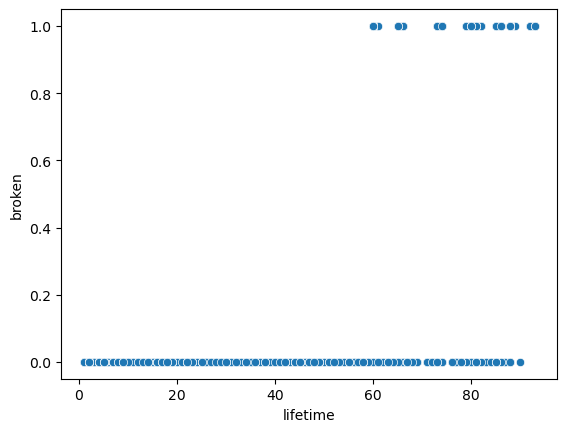

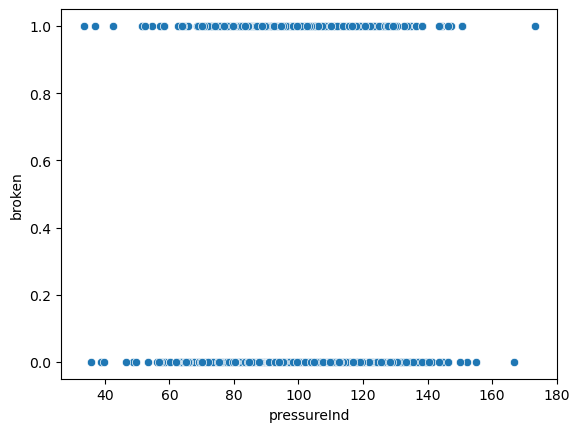

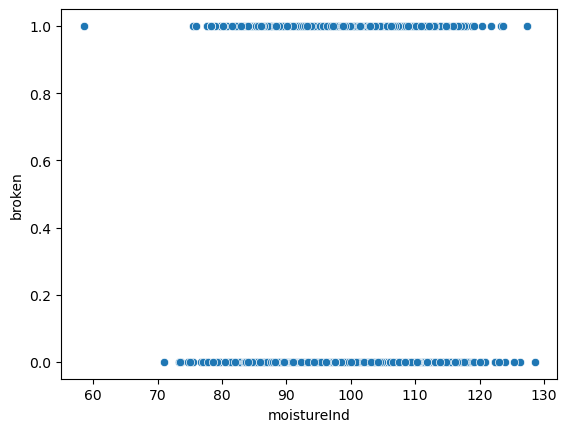

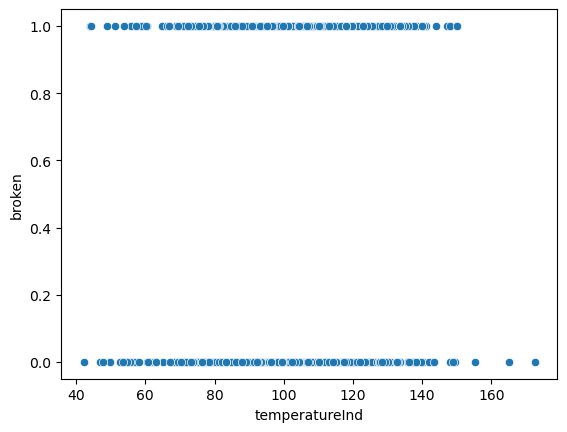

In [11]:
for i in ['lifetime','pressureInd','moistureInd','temperatureInd']:
    sns.scatterplot(x=main[i],y=main.broken)
    plt.show()

In [12]:
# c=main.corr()
# c

In [13]:
# sns.heatmap(c,annot=True)
# plt.show()

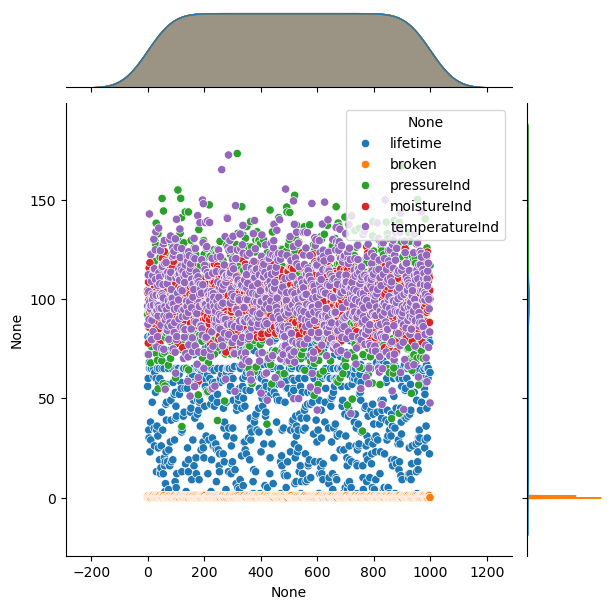

In [14]:
sns.jointplot(data=main)
plt.show()

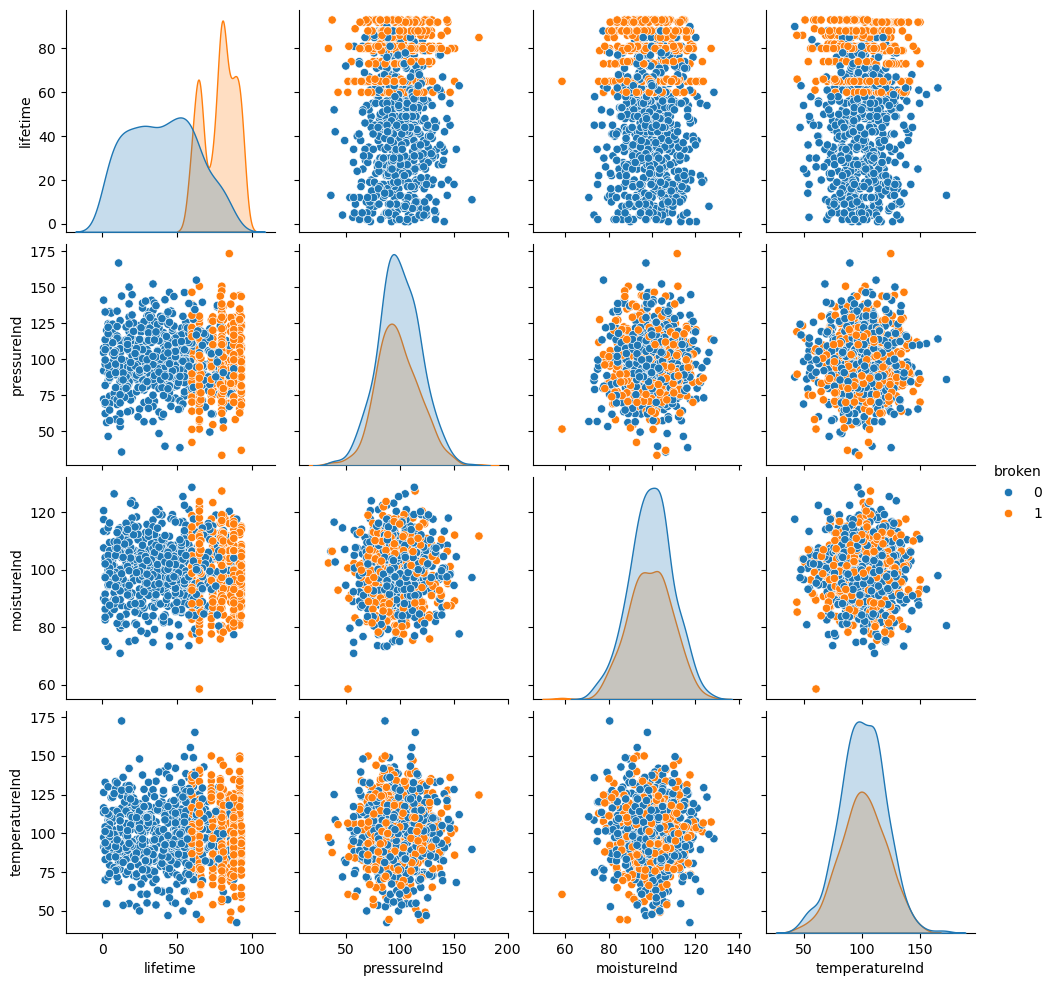

In [31]:
sns.pairplot(main,hue='broken')
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [33]:
main.team = le.fit_transform(main.team)
main.team.unique()

array([0, 2, 1])

In [34]:
le.inverse_transform([0,2,1])

array(['TeamA', 'TeamC', 'TeamB'], dtype=object)

In [35]:
main.provider = le.fit_transform(main.provider)
main.provider.unique()

array([3, 0, 1, 2])

In [36]:
le.inverse_transform([3,0,1,2])

array(['Provider4', 'Provider1', 'Provider2', 'Provider3'], dtype=object)

In [37]:
c = main.corr()
c

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
lifetime,1.000000,0.702656,0.000943,0.001196,0.001744,-0.046537,-0.025172
broken,0.702656,1.000000,-0.028942,-0.019520,0.015364,0.030876,-0.062972
pressureInd,0.000943,-0.028942,1.000000,0.020543,0.003641,-0.069528,-0.004337
moistureInd,0.001196,-0.019520,0.020543,1.000000,-0.009842,0.022420,0.028906
temperatureInd,0.001744,0.015364,0.003641,-0.009842,1.000000,0.007310,-0.010822
team,-0.046537,0.030876,-0.069528,0.022420,0.007310,1.000000,0.005606
provider,-0.025172,-0.062972,-0.004337,0.028906,-0.010822,0.005606,1.000000


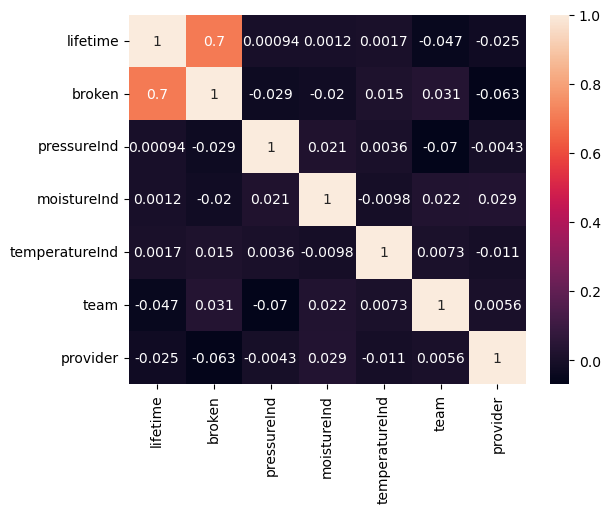

In [38]:
sns.heatmap(c,annot=True)
plt.show()

In [39]:
ip = main.drop('broken',axis=1)
op = main.broken

In [40]:
ip.head()

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
0,56,92.178854,104.230204,96.517159,0,3
1,81,72.075938,103.065701,87.271062,2,3
2,60,96.272254,77.801376,112.196170,0,0
3,86,94.406461,108.493608,72.025374,2,1
4,34,97.752899,99.413492,103.756271,1,0


In [41]:

op.head()

0    0
1    1
2    0
3    1
4    0
Name: broken, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.3,random_state=33)

In [43]:
x_train

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
875,35,113.435200,94.697923,95.785051,1,3
427,83,100.284861,102.433622,106.187552,0,3
35,65,69.134595,81.980122,81.033925,1,2
817,80,129.921744,104.598326,65.183467,1,0
715,19,115.527927,102.912478,92.379237,2,1
...,...,...,...,...,...,...
658,35,115.306204,105.926707,75.190619,1,2
578,80,95.323976,103.290379,109.411016,0,0
728,65,113.730144,102.254016,92.793026,1,2
391,80,107.312106,99.271973,102.030761,0,0


In [44]:
x_test

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
286,13,86.024851,80.532008,172.544140,1,0
402,60,109.117726,92.777645,98.686646,1,1
253,16,96.617132,110.210491,92.232821,1,0
4,34,97.752899,99.413492,103.756271,1,0
372,77,88.409106,96.967528,102.877008,1,0
...,...,...,...,...,...,...
98,53,121.673679,100.007684,130.303502,2,2
296,26,108.067833,106.343999,87.003807,0,0
913,81,101.637611,97.601783,118.043152,2,3
999,63,116.901354,99.998694,47.641493,1,0


In [45]:
y_test

286    0
402    0
253    0
4      0
372    0
      ..
98     0
296    0
913    1
999    0
829    0
Name: broken, Length: 300, dtype: int64

In [46]:
y_train

875    0
427    0
35     1
817    1
715    0
      ..
658    0
578    1
728    1
391    1
20     1
Name: broken, Length: 700, dtype: int64

In [47]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 6)
(300, 6)
(700,)
(300,)


In [48]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [49]:
x_train

array([[-0.79755071,  0.76083733, -0.44114604, -0.29110023,  0.0612395 ,
         1.4177272 ],
       [ 1.01850404,  0.10957495,  0.31689803,  0.24907062, -1.19957364,
         1.4177272 ],
       [ 0.33748351, -1.43312256, -1.68740112, -1.05708218,  0.0612395 ,
         0.51717453],
       ...,
       [ 0.33748351,  0.77544424,  0.29929799, -0.44646715,  0.0612395 ,
         0.51717453],
       [ 0.90500061,  0.45759491,  0.00707869,  0.03322089, -1.19957364,
        -1.2839308 ],
       [ 0.67799377,  0.09576075,  0.42167749, -0.23444866,  1.32205263,
        -1.2839308 ]])

In [50]:
x_test

array([[-1.51944391, -0.71407625, -2.04111834,  3.62319094, -0.02438058,
        -1.40604023],
       [ 0.26011911,  0.48049236, -0.74320552, -0.00800525, -0.02438058,
        -0.50086412],
       [-1.40585478, -0.16614936,  1.10449856, -0.32530689, -0.02438058,
        -1.40604023],
       ...,
       [ 1.05524301,  0.09355439, -0.23189602,  0.9436554 ,  1.19464826,
         1.30948811],
       [ 0.37370823,  0.88313076,  0.02215209, -2.51763502, -0.02438058,
        -1.40604023],
       [-0.34568958,  1.26890248, -0.27457845, -2.55620225, -1.24340941,
         0.404312  ]])

In [51]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [52]:
pred = lr.predict(x_test)
pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0], d

In [53]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(pred,y_test)
r2 = r2_score (pred,y_test)
print('Mean Square Error: ',mse)
print('R2 Score: ',r2)

Mean Square Error:  0.16666666666666666
R2 Score:  0.28499928499928506


In [54]:
df = pd.DataFrame({'Y_test':list(y_test),'Prediction':pred})
df

,Y_test,Prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
295,0,0
296,0,0
297,1,1
298,0,0


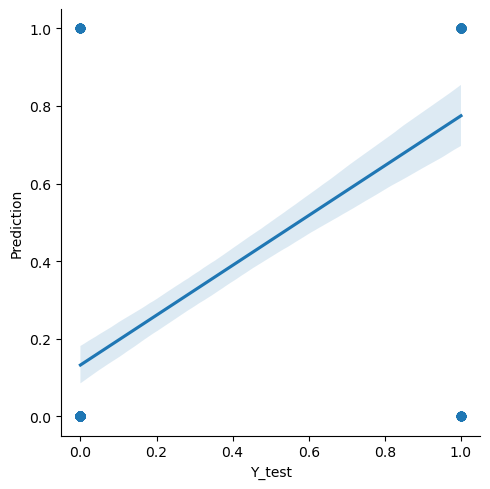

In [55]:
sns.lmplot(x='Y_test',y='Prediction',data=df)
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(pred, y_test)
re = recall_score(pred, y_test)
pr = precision_score(pred, y_test)
f1 = f1_score(pred, y_test)

print('Accuracy : ', ac)
print('Recall : ', re)
print('Precision : ', pr)
print('F1 Score : ',f1)

Accuracy :  0.8333333333333334
Recall :  0.7747747747747747
Precision :  0.7747747747747747
F1 Score :  0.7747747747747747


In [57]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(pred,y_test)
cm

array([[164,  25],
       [ 25,  86]], dtype=int64)

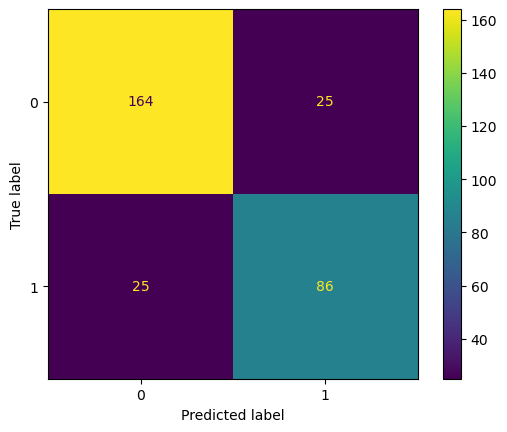

In [58]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [59]:
df = pd.DataFrame({'Y_test':list(y_test),'Prediction':pred})
df

,Y_test,Prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
295,0,0
296,0,0
297,1,1
298,0,0


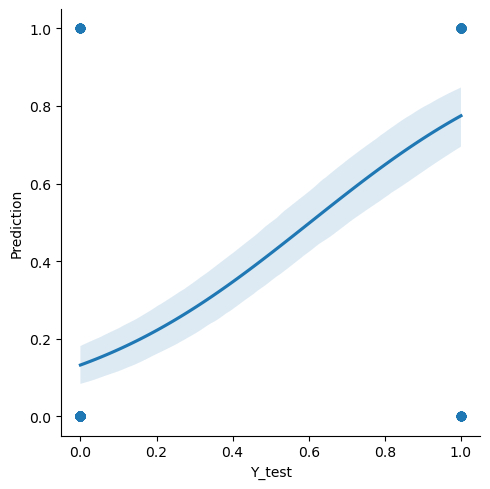

In [60]:
sns.lmplot(x='Y_test',y='Prediction',data=df,logistic=True)
plt.show()

# naive_bayes

In [61]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [62]:
pred = gnb.predict(x_test)
pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0], d

In [63]:
x_test

array([[-1.51944391, -0.71407625, -2.04111834,  3.62319094, -0.02438058,
        -1.40604023],
       [ 0.26011911,  0.48049236, -0.74320552, -0.00800525, -0.02438058,
        -0.50086412],
       [-1.40585478, -0.16614936,  1.10449856, -0.32530689, -0.02438058,
        -1.40604023],
       ...,
       [ 1.05524301,  0.09355439, -0.23189602,  0.9436554 ,  1.19464826,
         1.30948811],
       [ 0.37370823,  0.88313076,  0.02215209, -2.51763502, -0.02438058,
        -1.40604023],
       [-0.34568958,  1.26890248, -0.27457845, -2.55620225, -1.24340941,
         0.404312  ]])

In [64]:
y_test

286    0
402    0
253    0
4      0
372    0
      ..
98     0
296    0
913    1
999    0
829    0
Name: broken, Length: 300, dtype: int64

In [65]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(pred, y_test)
re = recall_score(pred, y_test)
pr = precision_score(pred, y_test)
f1 = f1_score(pred, y_test)

print('Accuracy : ', ac)
print('Recall : ', re)
print('Precision : ', pr)
print('F1 Score : ',f1)

Accuracy :  0.8566666666666667
Recall :  0.7575757575757576
Precision :  0.9009009009009009
F1 Score :  0.823045267489712


In [66]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(pred,y_test)
cm

array([[157,  11],
       [ 32, 100]], dtype=int64)

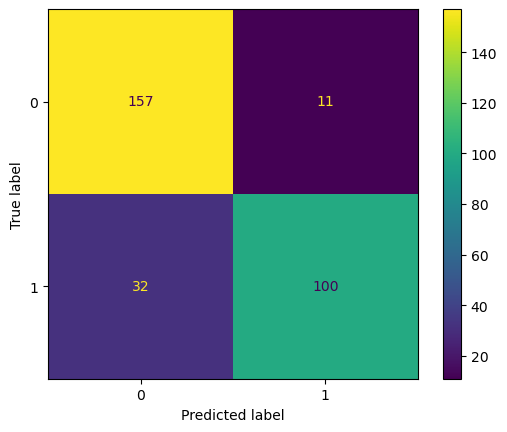

In [67]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [68]:
df = pd.DataFrame({'Y_test':list(y_test),'Prediction':pred})
df

,Y_test,Prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
295,0,0
296,0,0
297,1,1
298,0,1


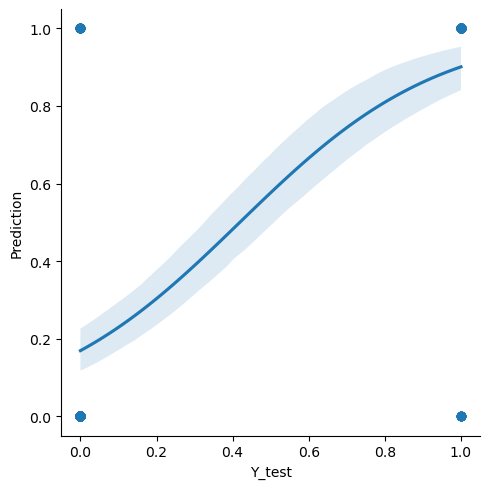

In [69]:
sns.lmplot(x='Y_test',y='Prediction',data=df,logistic=True)
plt.show()

# knn

In [70]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=11)

In [71]:
pred = knn.predict(x_test)
pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0], d

In [72]:
x_train

array([[-0.79755071,  0.76083733, -0.44114604, -0.29110023,  0.0612395 ,
         1.4177272 ],
       [ 1.01850404,  0.10957495,  0.31689803,  0.24907062, -1.19957364,
         1.4177272 ],
       [ 0.33748351, -1.43312256, -1.68740112, -1.05708218,  0.0612395 ,
         0.51717453],
       ...,
       [ 0.33748351,  0.77544424,  0.29929799, -0.44646715,  0.0612395 ,
         0.51717453],
       [ 0.90500061,  0.45759491,  0.00707869,  0.03322089, -1.19957364,
        -1.2839308 ],
       [ 0.67799377,  0.09576075,  0.42167749, -0.23444866,  1.32205263,
        -1.2839308 ]])

In [73]:
y_train

875    0
427    0
35     1
817    1
715    0
      ..
658    0
578    1
728    1
391    1
20     1
Name: broken, Length: 700, dtype: int64

In [74]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(pred, y_test)
re = recall_score(pred, y_test)
pr = precision_score(pred, y_test)
f1 = f1_score(pred, y_test)

print('Accuracy : ', ac)
print('Recall : ', re)
print('Precision : ', pr)
print('F1 Score : ',f1)

Accuracy :  0.8166666666666667
Recall :  0.7121212121212122
Precision :  0.8468468468468469
F1 Score :  0.7736625514403292


In [75]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(pred,y_test)
cm

array([[151,  17],
       [ 38,  94]], dtype=int64)

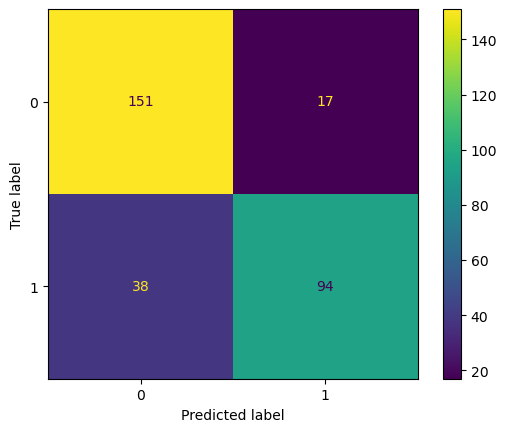

In [76]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

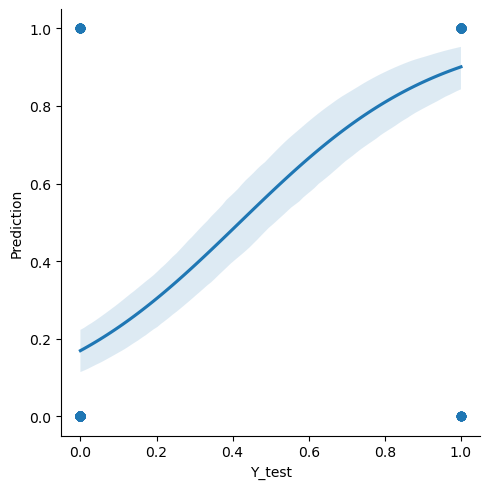

In [77]:
sns.lmplot(x='Y_test',y='Prediction',data=df,logistic=True)
plt.show()

# svm support vector machine

In [78]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf',gamma=0.01,C=1000)
svc.fit(x_train,y_train)

SVC(C=1000, gamma=0.01)

In [79]:
pred = knn.predict(x_test)
pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0], d

In [80]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(pred, y_test)
re = recall_score(pred, y_test)
pr = precision_score(pred, y_test)
f1 = f1_score(pred, y_test)

print('Accuracy : ', ac)
print('Recall : ', re)
print('Precision : ', pr)
print('F1 Score : ',f1)

Accuracy :  0.8166666666666667
Recall :  0.7121212121212122
Precision :  0.8468468468468469
F1 Score :  0.7736625514403292


In [81]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(pred,y_test)
cm

array([[151,  17],
       [ 38,  94]], dtype=int64)

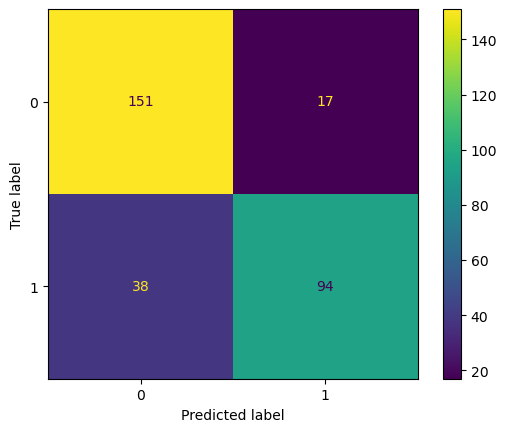

In [82]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

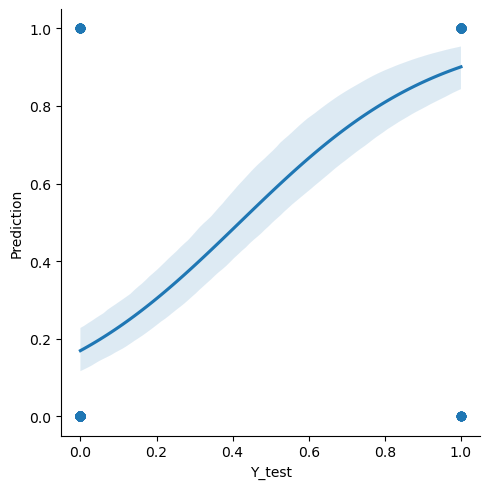

In [83]:
sns.lmplot(x='Y_test',y='Prediction',data=df,logistic=True)
plt.show()